In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
path_to_file = "calibration_results_template.csv"
#path_to_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_run_prefactor_test_overnight/calibration_results.csv"
df = pd.read_csv(path_to_file)

In [2]:
param_config = {
    "multiplier_for_degreeDayFactor": {"bounds": (0.5, 5.0), "initial": 1.0},
    "multiplier_for_minSoilDepthFrac": {"bounds": (0.5, 5.0), "initial": 1.0},
    "multiplier_for_kSat": {"bounds": (0.5, 5.0), "initial": 1.0},
    "multiplier_for_storCap": {"bounds": (0.5, 5.0), "initial": 1.0},
    "multiplier_for_recessionCoeff": {"bounds": (0.5, 5.0), "initial": 1.0},
    "referenceEPotFactor": {"bounds": (0.5, 2.0), "initial": 1.0},
    "precipitationFactor": {"bounds": (0.5, 2.0), "initial": 1.0},
    "manningsN": {"bounds": (0.005, 0.1), "initial": 0.04},
    "floodplain_manningsN": {"bounds": (0.005, 0.1), "initial": 0.04},
}

n_best = 10



In [3]:
df.columns

Index(['run_tag', 'timestamp', 'objective_value',
       'multiplier_for_degreeDayFactor', 'multiplier_for_minSoilDepthFrac',
       'multiplier_for_kSat', 'multiplier_for_storCap',
       'multiplier_for_recessionCoeff', 'referenceEPotFactor',
       'precipitationFactor', 'manningsN', 'floodplain_manningsN',
       'nse_Chatly', 'kge_Chatly', 'obj_Chatly', 'nse_Garm', 'kge_Garm',
       'obj_Garm', 'nse_Uch-Kurgan', 'kge_Uch-Kurgan', 'obj_Uch-Kurgan'],
      dtype='object')

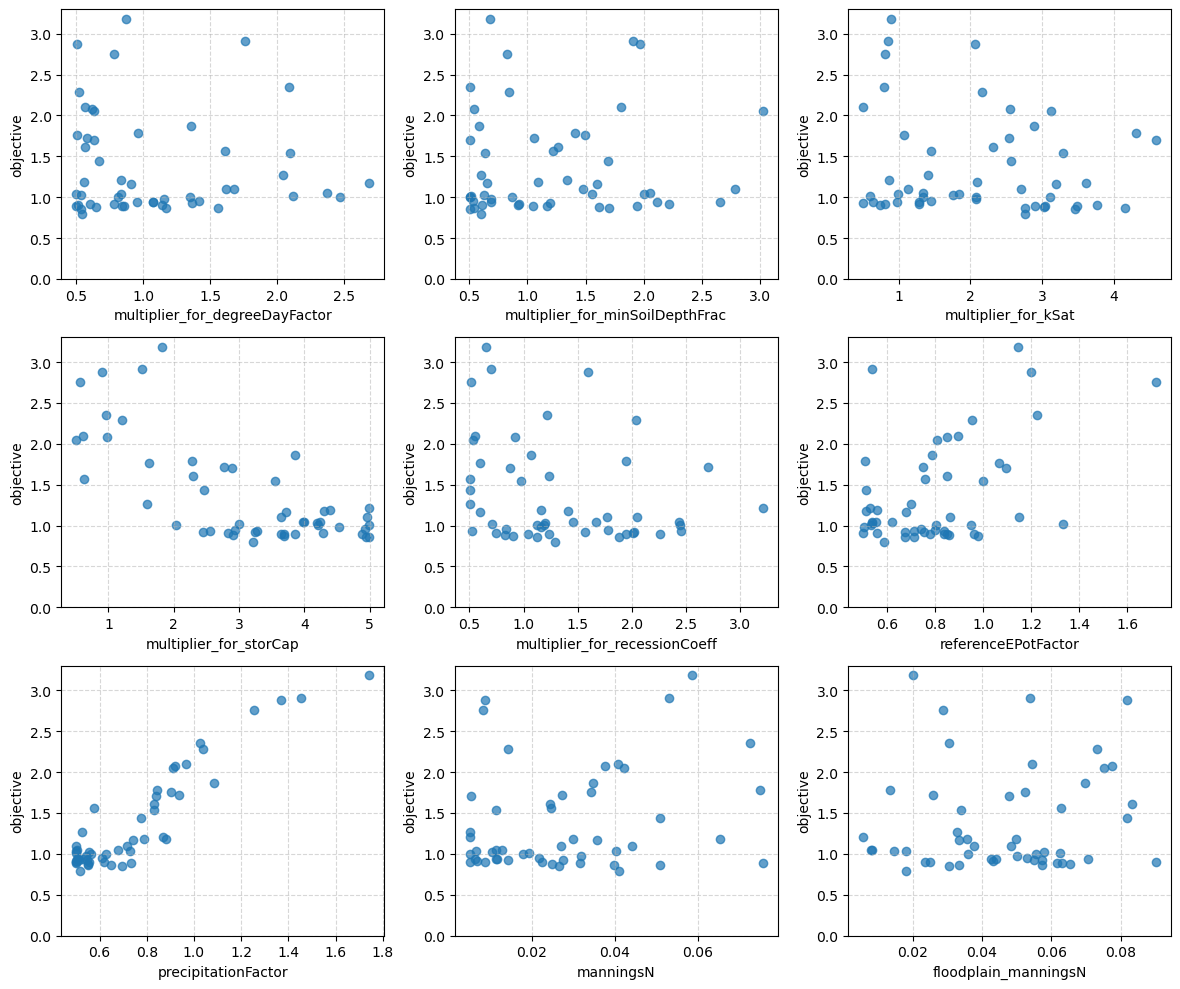

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(param_config):
    axes[i].scatter(df[p], df["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_ylim(bottom=0)

for j in range(len(param_config), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

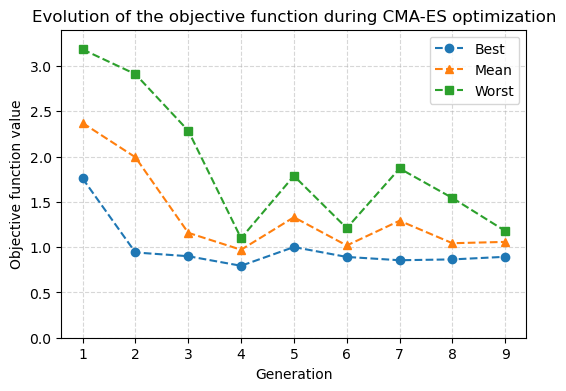

In [5]:
popsize = 6

df["generation"] = df.index // popsize

best_per_gen = df.groupby("generation")["objective_value"].min()
mean_per_gen = df.groupby("generation")["objective_value"].mean()
worst_per_gen = df.groupby("generation")["objective_value"].max()

plt.figure(figsize=(6,4))
plt.plot(best_per_gen.index+1, best_per_gen.values, linestyle="--", marker="o", label ="Best")
plt.plot(mean_per_gen.index+1, mean_per_gen.values, linestyle="--", marker="^", label="Mean")
plt.plot(worst_per_gen.index+1, worst_per_gen.values, linestyle="--", marker="s", label="Worst")

x = list(range(1, len(best_per_gen)+1))
plt.xticks(ticks=x, labels=x)

plt.xlabel("Generation")
plt.ylabel("Objective function value")
plt.title("Evolution of the objective function during CMA-ES optimization")
plt.legend()
plt.ylim(bottom=0, top=3.4)
plt.grid(linestyle="--", alpha=0.5)

plt.show()

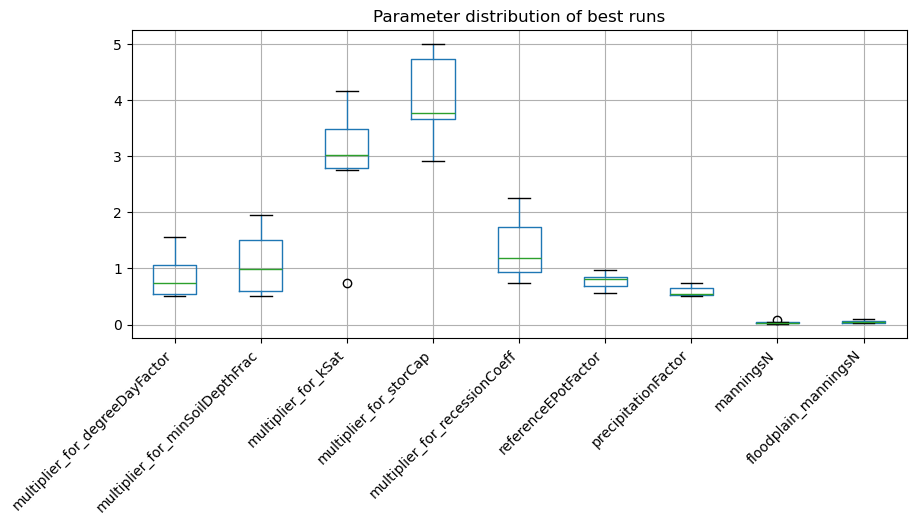

In [6]:
params = [p for p in param_config.keys() if p in df.columns]
best = df.nsmallest(n_best, "objective_value")

best[params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(params) + 1),
    labels=params,
    rotation=45,
    ha="right",
)

plt.title("Parameter distribution of best runs")
plt.show()

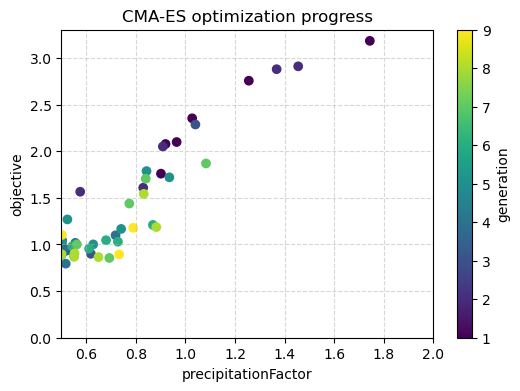

In [7]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    df["precipitationFactor"],
    df["objective_value"],
    c=df["generation"]+1,
)

plt.colorbar(sc, label="generation")
plt.xlabel("precipitationFactor")
plt.ylabel("objective")
plt.grid(linestyle="--", alpha=0.5)
plt.ylim(bottom=0)
plt.xlim(0.5, 2.0)

plt.title("CMA-ES optimization progress")

plt.show()

In [8]:
# create scaled dataframe
df_scaled = df.copy()

for param, cfg in param_config.items():
    if param not in df.columns:
        continue
    lower, upper = cfg["bounds"]
    df_scaled[f"{param}_scaled"] = (df[param] - lower) / (upper - lower)

df_scaled.head()

,run_tag,timestamp,objective_value,multiplier_for_degreeDayFactor,multiplier_for_minSoilDepthFrac,multiplier_for_kSat,multiplier_for_storCap,multiplier_for_recessionCoeff,referenceEPotFactor,precipitationFactor,...,generation,multiplier_for_degreeDayFactor_scaled,multiplier_for_minSoilDepthFrac_scaled,multiplier_for_kSat_scaled,multiplier_for_storCap_scaled,multiplier_for_recessionCoeff_scaled,referenceEPotFactor_scaled,precipitationFactor_scaled,manningsN_scaled,floodplain_manningsN_scaled
0,96c0151b,2026-03-18 10:37:47,1.758929,0.503419,1.491661,1.081462,1.624297,0.599657,1.065245,0.901480,...,0,0.000760,0.220369,0.129214,0.249844,0.022146,0.376830,0.267654,0.309038,0.497545
1,e0d1dcf0,2026-03-18 10:37:47,2.352645,2.088159,0.501755,0.803042,0.954861,1.211689,1.224223,1.027351,...,0,0.352924,0.000390,0.067343,0.101080,0.158153,0.482815,0.351567,0.711683,0.268493
2,7e20278d,2026-03-18 10:37:47,2.098152,0.569635,1.803378,0.511991,0.604779,0.546620,0.893684,0.964671,...,0,0.015474,0.289640,0.002665,0.023284,0.010360,0.262456,0.309781,0.377353,0.519677
3,30006c43,2026-03-18 11:10:31,2.755730,0.783294,0.822236,0.807033,0.559119,0.510587,1.720848,1.255687,...,0,0.062954,0.071608,0.068230,0.013138,0.002353,0.813899,0.503792,0.033454,0.249091
4,e349e2c9,2026-03-18 11:10:31,2.076982,0.616432,0.538925,2.544488,0.982042,0.920099,0.850319,0.919973,...,0,0.025874,0.008650,0.454331,0.107120,0.093355,0.233546,0.279982,0.344144,0.763152


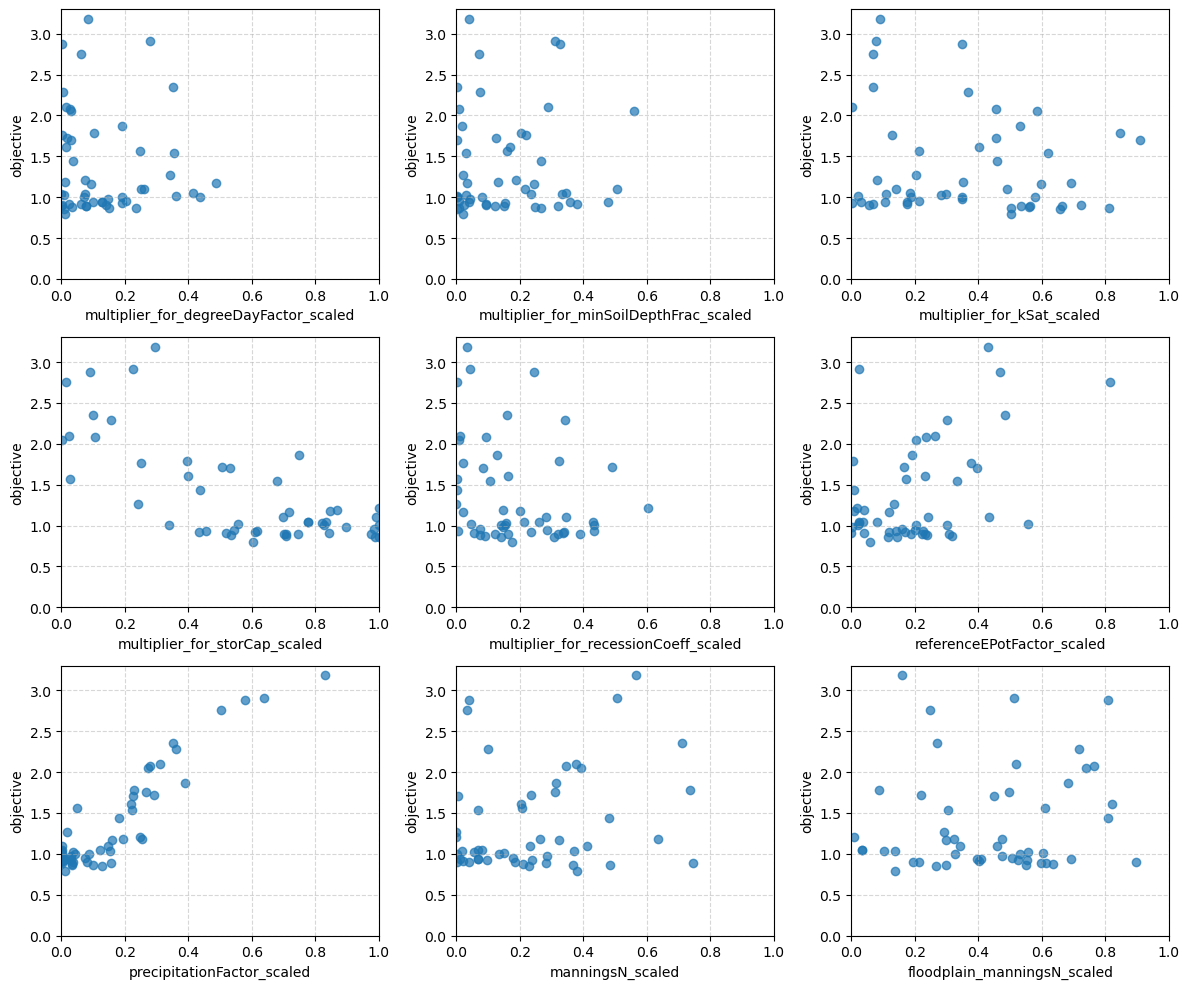

In [9]:

scaled_params = [p + "_scaled" for p in param_config.keys()]

fig, axes = plt.subplots(3,3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(scaled_params):
    axes[i].scatter(df_scaled[p], df_scaled["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_xlim(0,1)
    axes[i].set_ylim(bottom=0)

for j in range(len(scaled_params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

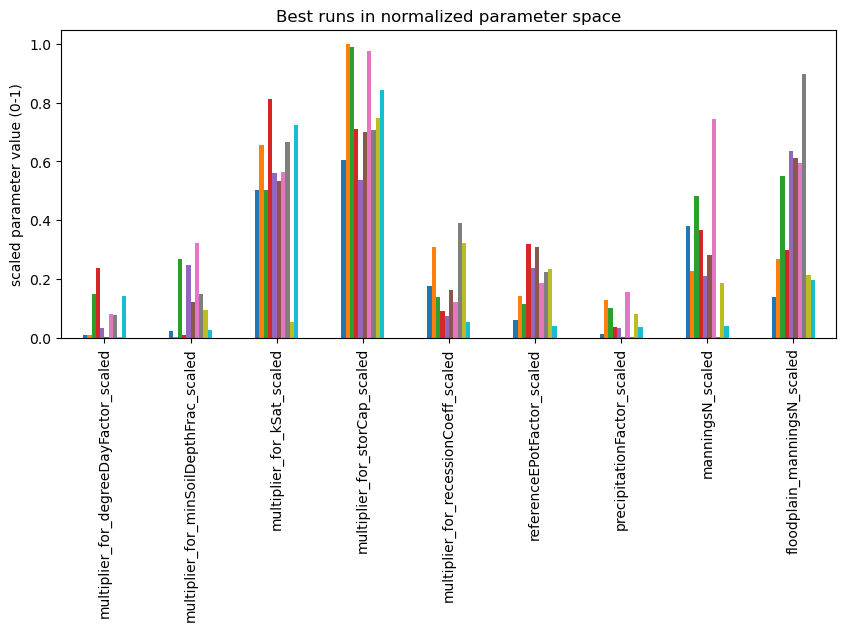

In [10]:

best = df_scaled.nsmallest(n_best, "objective_value")

best[[p + "_scaled" for p in param_config]].T.plot(
    kind="bar",
    legend=False,
    figsize=(10,4)
)

plt.ylabel("scaled parameter value (0-1)")
plt.title("Best runs in normalized parameter space")
plt.show()

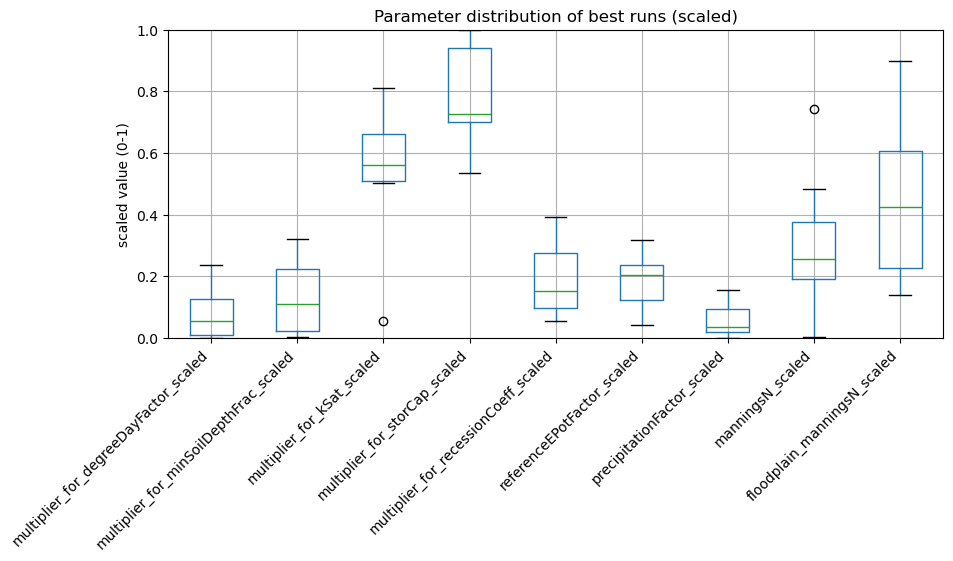

In [11]:
best = df_scaled.nsmallest(n_best, "objective_value")

scaled_params = [p + "_scaled" for p in param_config]

best[scaled_params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(scaled_params) + 1),
    labels=scaled_params,
    rotation=45,
    ha="right",
)
plt.ylim(0, 1)

plt.ylabel("scaled value (0-1)")
plt.title("Parameter distribution of best runs (scaled)")
plt.show()

In [12]:
# # Select only good runs (important!)
df_good = df[df["objective_value"] <= 3]

# corrs = {}

# for p in param_config:
#     corrs[p] = df_good[p].corr(df_good["objective_value"])

# # Sort by absolute importance
# corrs = pd.Series(corrs).sort_values(key=lambda x: abs(x), ascending=False)

# print(corrs)

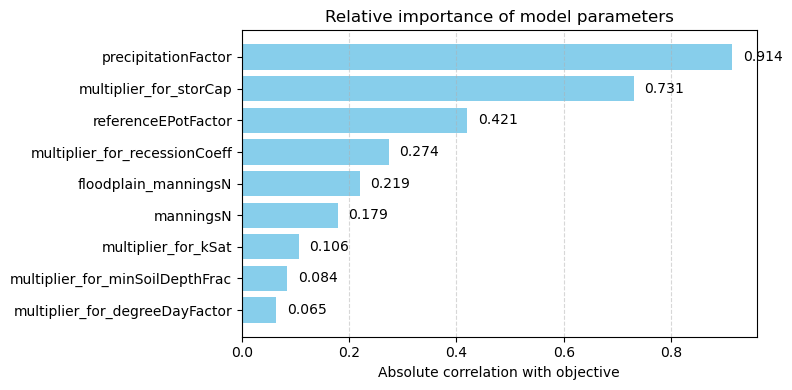

In [13]:
log_params = {
    "multiplier_for_kSat",
    "multiplier_for_recessionCoeff",
    # add all multipliers applied in log-space
}

# example in correlation loop:


corrs = {}
for p in param_config:
    if p in df_good.columns:
        x = np.log10(df_good[p]) if p in log_params else df_good[p]
        corrs[p] = x.corr(df_good["objective_value"])
        #corrs[p] = df_good[p].corr(df_good["objective_value"])

corrs = pd.Series(corrs).dropna().sort_values(key=lambda x: x.abs(), ascending=False)

# params and absolute correlations
params = corrs.index.tolist()
values = corrs.abs().tolist()



plt.figure(figsize=(8,4))
plt.barh(params, values, color="skyblue")
plt.xlabel("Absolute correlation with objective")
plt.title("Relative importance of model parameters")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(values):
    plt.text(v + 0.02, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [14]:
corrs

precipitationFactor                0.914157
multiplier_for_storCap            -0.730810
referenceEPotFactor                0.420646
multiplier_for_recessionCoeff     -0.274026
floodplain_manningsN               0.219412
manningsN                          0.178845
multiplier_for_kSat               -0.105768
multiplier_for_minSoilDepthFrac    0.083997
multiplier_for_degreeDayFactor    -0.064533
dtype: float64